# Greatest Euclidean Distance

Given a list of points in a high dimensional space, find the pair of points with the greatest Euclidean distance between them.

## Setup

### Import libraries

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import distance

### Define data

In [53]:
points = pd.DataFrame({
    'Name': [c for c in 'ABCDEFGH'],
    '_i': np.random.randint(1, 6, 8),
    '_j': np.random.randint(1, 6, 8),
    '_k': np.random.randint(1, 6, 8),
    '_l': np.random.randint(1, 6, 8),
    '_m': np.random.randint(1, 6, 8),
    '_n': np.random.randint(1, 6, 8),
})
features = ['_i', '_j', '_k', '_l', '_m', '_n']
points

,Name,_i,_j,_k,_l,_m,_n
0,A,3,1,1,2,2,2
1,B,2,1,3,1,5,5
2,C,3,3,1,2,3,5
3,D,3,1,3,3,4,4
4,E,5,3,3,1,2,1
5,F,5,5,3,5,2,1
6,G,2,5,4,2,4,2
7,H,4,4,4,5,3,5


## Compute distances

In [54]:
distances = pd.DataFrame(distance.cdist(points[features], points[features], 'eu'))
distances

,0,1,2,3,4,5,6,7
0,0.000000,4.898979,3.741657,3.605551,3.741657,5.830952,5.477226,6.164414
1,4.898979,0.000000,3.741657,2.645751,6.164414,8.124038,5.291503,5.830952
2,3.741657,3.741657,0.000000,3.316625,5.099020,6.164414,4.898979,4.472136
3,3.605551,2.645751,3.316625,0.000000,5.000000,6.082763,4.795832,4.123106
4,3.741657,6.164414,5.099020,5.000000,0.000000,4.472136,4.472136,6.000000
5,5.830952,8.124038,6.164414,6.082763,4.472136,0.000000,4.898979,4.472136
6,5.477226,5.291503,4.898979,4.795832,4.472136,4.898979,0.000000,4.898979
7,6.164414,5.830952,4.472136,4.123106,6.000000,4.472136,4.898979,0.000000


## Visualize distances with a heatmap

<Axes: >

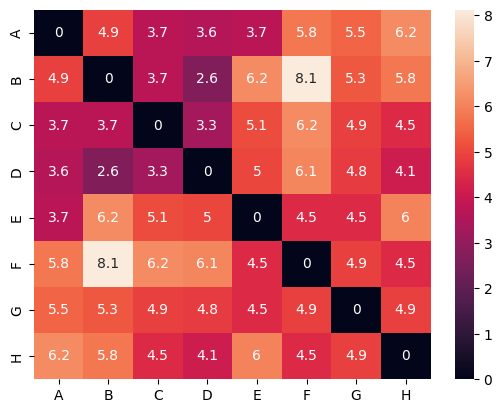

In [55]:
sns.heatmap(distances, annot=True, xticklabels=points['Name'], yticklabels=points['Name'])

## Find the max distance

In [56]:
max_distance = distances.max().max()
print(f'Max distance: {max_distance}')

Max distance: 8.12403840463596


## Find and name the point pairs with that distance

In [57]:
for i in range(len(points)):
    for j in range(i+1, len(points)):
        if distances.iloc[i,j] == max_distance:
            print(f'{points.iloc[i,0]} and {points.iloc[j,0]} are the farthest apart.')

B and F are the farthest apart.
